# Comprension EDA - Proyecto Integrador M5 Avance 1

Este notebook desarrolla la exploracion experimental y descriptiva exigida para el avance 1. El objetivo es entender la base de creditos, revisar calidad de datos, documentar relaciones con `Pago_atiempo` y proponer reglas de validacion y transformaciones para los avances de modelado, monitoreo y despliegue.

## 1. Configuracion

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "src" else Path.cwd()
if (PROJECT_DIR / "mlops_pipeline").exists():
    PROJECT_DIR = PROJECT_DIR / "mlops_pipeline"
SRC_DIR = PROJECT_DIR / "src"
sys.path.insert(0, str(SRC_DIR))

from ft_engineering import (
    DATE_COLUMN,
    REQUIRED_COLUMNS,
    TARGET,
    add_features,
    clean_data,
    load_data,
)

DATA_PATH = PROJECT_DIR / "Base_de_datos.csv"
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid")

## 2. Carga y limpieza reutilizable

Se cargan datos crudos y se aplica la limpieza centralizada. Esto asegura que el EDA, el entrenamiento y la API trabajen bajo la misma logica.

In [2]:
raw_df = load_data(DATA_PATH)
df = clean_data(raw_df)
featured_df = add_features(df)
print(f"Base cruda: {raw_df.shape}")
print(f"Base limpia: {df.shape}")
print(f"Base con features: {featured_df.shape}")
df.head()

Base cruda: (10763, 23)
Base limpia: (10763, 24)
Base con features: (10763, 37)


,loan_id,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,REQ000000,7,2024-12-21 11:31:34.999999368,"3,692,160.0000",10,42,Independiente,8000000,2500000,341296,88.7681,695.0000,10,5,0.0000,"51,258.0000","51,258.0000",0.0000,5,0,0,"908,526.0000",Estable,1
1,REQ000001,4,2025-04-22 09:47:34.999999768,"840,000.0000",6,60,Empleado,3000000,2000000,124876,95.2278,789.0000,3,1,0.0000,"8,673.0000","8,673.0000",0.0000,0,0,2,"939,017.0000",Creciente,1
2,REQ000002,9,2026-01-08 12:22:39.999999823,"5,974,028.4000",10,36,Independiente,4036000,829000,529554,47.6139,740.0000,4,5,0.0000,"18,702.0000","18,702.0000",0.0000,3,0,0,NaN,Desconocido,0
3,REQ000003,4,2025-08-04 12:04:09.999999972,"1,671,240.0000",6,48,Empleado,1524547,498000,252420,95.2278,837.0000,4,4,0.0000,"15,782.0000","15,782.0000",0.0000,3,0,0,"1,536,193.0000",Creciente,1
4,REQ000004,9,2025-04-26 11:24:26.000000291,"2,781,636.0000",11,44,Empleado,5000000,4000000,217037,95.2278,771.0000,4,6,0.0000,"204,804.0000","204,804.0000",0.0000,3,0,1,"933,473.0000",Creciente,1


## 3. Descripcion general y caracterizacion de variables

Se clasifica cada columna por tipo analitico. Esto ayuda a decidir graficos, transformaciones e imputaciones.

In [3]:
variable_catalog = pd.DataFrame({
    "columna": [
        "loan_id", "tipo_credito", "fecha_prestamo", "capital_prestado", "plazo_meses",
        "edad_cliente", "tipo_laboral", "salario_cliente", "total_otros_prestamos",
        "cuota_pactada", "puntaje", "puntaje_datacredito", "cant_creditosvigentes",
        "huella_consulta", "saldo_mora", "saldo_total", "saldo_principal",
        "saldo_mora_codeudor", "creditos_sectorFinanciero", "creditos_sectorCooperativo",
        "creditos_sectorReal", "promedio_ingresos_datacredito", "tendencia_ingresos", TARGET
    ],
    "tipo_analitico": [
        "identificador", "categorica nominal politomica", "fecha", "numerica continua",
        "numerica discreta ordinal", "numerica discreta", "categorica nominal dicotomica",
        "numerica continua", "numerica continua", "numerica continua", "numerica continua",
        "numerica continua", "numerica discreta", "numerica discreta", "numerica continua",
        "numerica continua", "numerica continua", "numerica continua", "numerica discreta",
        "numerica discreta", "numerica discreta", "numerica continua",
        "categorica ordinal politomica", "binaria dicotomica"
    ],
    "uso": [
        "tecnico", "input", "orden temporal", "input", "input", "input", "input", "input",
        "input", "input", "input", "input", "input", "input", "input", "input",
        "input", "input", "input", "input", "input", "input", "input", "objetivo"
    ]
})
variable_catalog

,columna,tipo_analitico,uso
0,loan_id,identificador,tecnico
1,tipo_credito,categorica nominal politomica,input
2,fecha_prestamo,fecha,orden temporal
3,capital_prestado,numerica continua,input
4,plazo_meses,numerica discreta ordinal,input
5,edad_cliente,numerica discreta,input
6,tipo_laboral,categorica nominal dicotomica,input
7,salario_cliente,numerica continua,input
8,total_otros_prestamos,numerica continua,input
9,cuota_pactada,numerica continua,input


## 4. Nulos y unificacion de valores faltantes

Los vacios se unifican como `NaN`; en categoricas se usa `Desconocido` para no perder registros. Las columnas con mas nulos son candidatas a imputacion y monitoreo.

In [4]:
nulls_before = raw_df.replace(r"^\s*$", pd.NA, regex=True).isna().sum()
nulls_after = df.isna().sum()
null_report = pd.DataFrame({
    "nulos_crudo": nulls_before,
    "nulos_limpio": nulls_after.reindex(raw_df.columns, fill_value=0),
})
null_report["pct_nulos_crudo"] = (null_report["nulos_crudo"] / len(raw_df) * 100).round(2)
null_report.sort_values("nulos_crudo", ascending=False).head(12)

,nulos_crudo,nulos_limpio,pct_nulos_crudo
tendencia_ingresos,2932,0,27.2400
promedio_ingresos_datacredito,2930,2930,27.2200
saldo_mora_codeudor,590,590,5.4800
saldo_principal,405,405,3.7600
saldo_mora,156,156,1.4500
saldo_total,156,156,1.4500
puntaje_datacredito,6,6,0.0600
salario_cliente,0,0,0.0000
tipo_laboral,0,0,0.0000
edad_cliente,0,0,0.0000


## 5. Variables irrelevantes o de uso especial

`loan_id` se crea como identificador tecnico y no debe entrar al modelo. `fecha_prestamo` tampoco entra directamente: se transforma en `prestamo_year` y `prestamo_month` para evitar que el modelo reciba una fecha cruda dificil de interpretar.

In [5]:
irrelevant_or_special = pd.DataFrame({
    "columna": ["loan_id", "fecha_prestamo"],
    "decision": ["Excluir del entrenamiento", "Transformar a year/month y usar para split temporal"],
    "razon": [
        "Identifica registros, no aporta patron generalizable.",
        "La fecha cruda puede inducir ruido; tambien sirve para separar historico vs reciente."
    ]
})
irrelevant_or_special

,columna,decision,razon
0,loan_id,Excluir del entrenamiento,"Identifica registros, no aporta patron general..."
1,fecha_prestamo,Transformar a year/month y usar para split tem...,La fecha cruda puede inducir ruido; tambien si...


## 6. Tipos corregidos

Despues de limpiar, las variables numericas quedan como numeros, la fecha como datetime y las categorias como texto normalizado.

In [6]:
pd.DataFrame({
    "dtype_crudo": raw_df.dtypes.astype(str),
    "dtype_limpio": df.drop(columns=["loan_id"]).dtypes.astype(str),
}).fillna("creada_en_limpieza")

,dtype_crudo,dtype_limpio
tipo_credito,int64,str
fecha_prestamo,float64,datetime64[ns]
capital_prestado,float64,float64
plazo_meses,int64,int64
edad_cliente,int64,int64
tipo_laboral,str,str
salario_cliente,int64,int64
total_otros_prestamos,int64,int64
cuota_pactada,int64,int64
puntaje,float64,float64


## 7. Analisis univariable numerico

Se revisan medidas de tendencia central y dispersion. En creditos suelen existir colas largas, por lo que la mediana y los cuartiles son tan importantes como el promedio.

In [7]:
numeric_cols = df.select_dtypes(include="number").columns.drop(TARGET)
describe_numeric = df[numeric_cols].describe().T
describe_numeric["rango"] = describe_numeric["max"] - describe_numeric["min"]
describe_numeric["iqr"] = describe_numeric["75%"] - describe_numeric["25%"]
describe_numeric["skewness"] = df[numeric_cols].skew(numeric_only=True)
describe_numeric["kurtosis"] = df[numeric_cols].kurtosis(numeric_only=True)
describe_numeric.sort_values("iqr", ascending=False).head(15)

,count,mean,std,min,25%,50%,75%,max,rango,iqr,skewness,kurtosis
salario_cliente,"10,763.0000","17,216,431.4599","355,476,717.6035",0.0000,"2,000,000.0000","3,000,000.0000","4,875,808.0000","22,000,000,000.0000","22,000,000,000.0000","2,875,808.0000",43.7767,"2,211.2301"
capital_prestado,"10,763.0000","2,434,315.0013","1,909,642.7590","360,000.0000","1,224,831.0000","1,921,920.0000","3,084,840.0000","41,444,152.8000","41,084,152.8000","1,860,009.0000",3.7239,35.3181
total_otros_prestamos,"10,763.0000","6,238,869.6485","118,418,316.9411",0.0000,"500,000.0000","1,000,000.0000","2,000,000.0000","6,787,675,263.0000","6,787,675,263.0000","1,500,000.0000",38.4639,"1,719.2809"
promedio_ingresos_datacredito,"7,833.0000","2,005,156.8118","2,144,116.1503",0.0000,"925,157.0000","1,204,496.0000","2,231,859.0000","38,106,581.0000","38,106,581.0000","1,306,702.0000",4.2802,32.7707
cuota_pactada,"10,763.0000","243,617.4067","210,493.6946","23,944.0000","121,041.5000","182,863.0000","287,833.5000","3,816,752.0000","3,792,808.0000","166,792.0000",3.7933,26.6508
saldo_total,"10,607.0000","45,937.4081","106,269.7899",0.0000,"2,898.0000","16,178.0000","52,982.0000","5,116,066.0000","5,116,066.0000","50,084.0000",20.1977,789.1667
saldo_principal,"10,358.0000","40,346.1682","71,242.4403",0.0000,"2,690.0000","14,442.5000","47,632.2500","1,562,285.0000","1,562,285.0000","44,942.2500",5.0502,51.0638
puntaje_datacredito,"10,757.0000",780.7908,104.8780,-7.0000,757.0000,791.0000,825.0000,999.0000,"1,006.0000",68.0000,-5.6445,39.4378
edad_cliente,"10,763.0000",43.9486,15.0609,19.0000,33.0000,42.0000,53.0000,123.0000,104.0000,20.0000,1.9344,7.8689
plazo_meses,"10,763.0000",10.5756,6.6321,2.0000,6.0000,10.0000,12.0000,90.0000,88.0000,6.0000,2.4597,7.7801


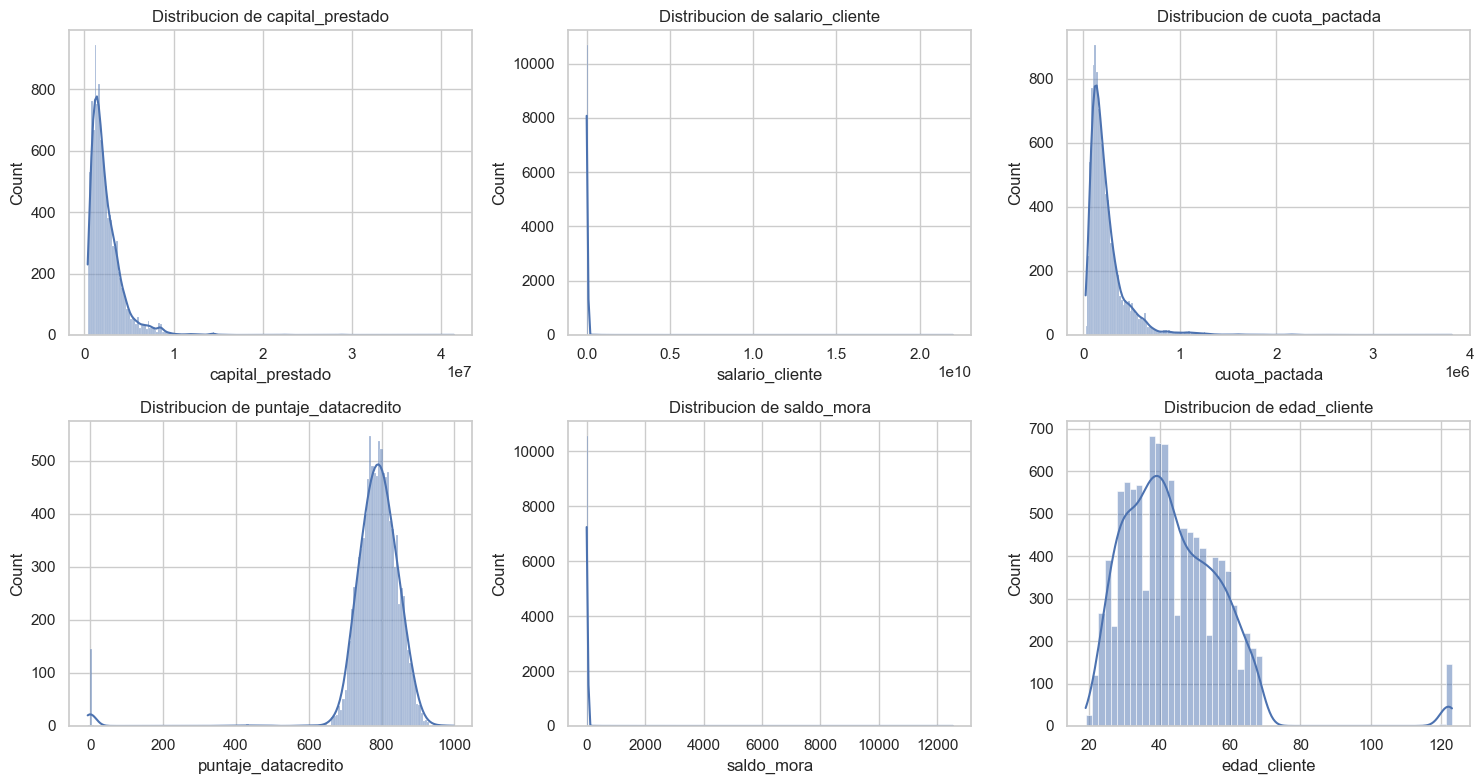

In [8]:
plot_cols = ["capital_prestado", "salario_cliente", "cuota_pactada", "puntaje_datacredito", "saldo_mora", "edad_cliente"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), plot_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"Distribucion de {col}")
plt.tight_layout()

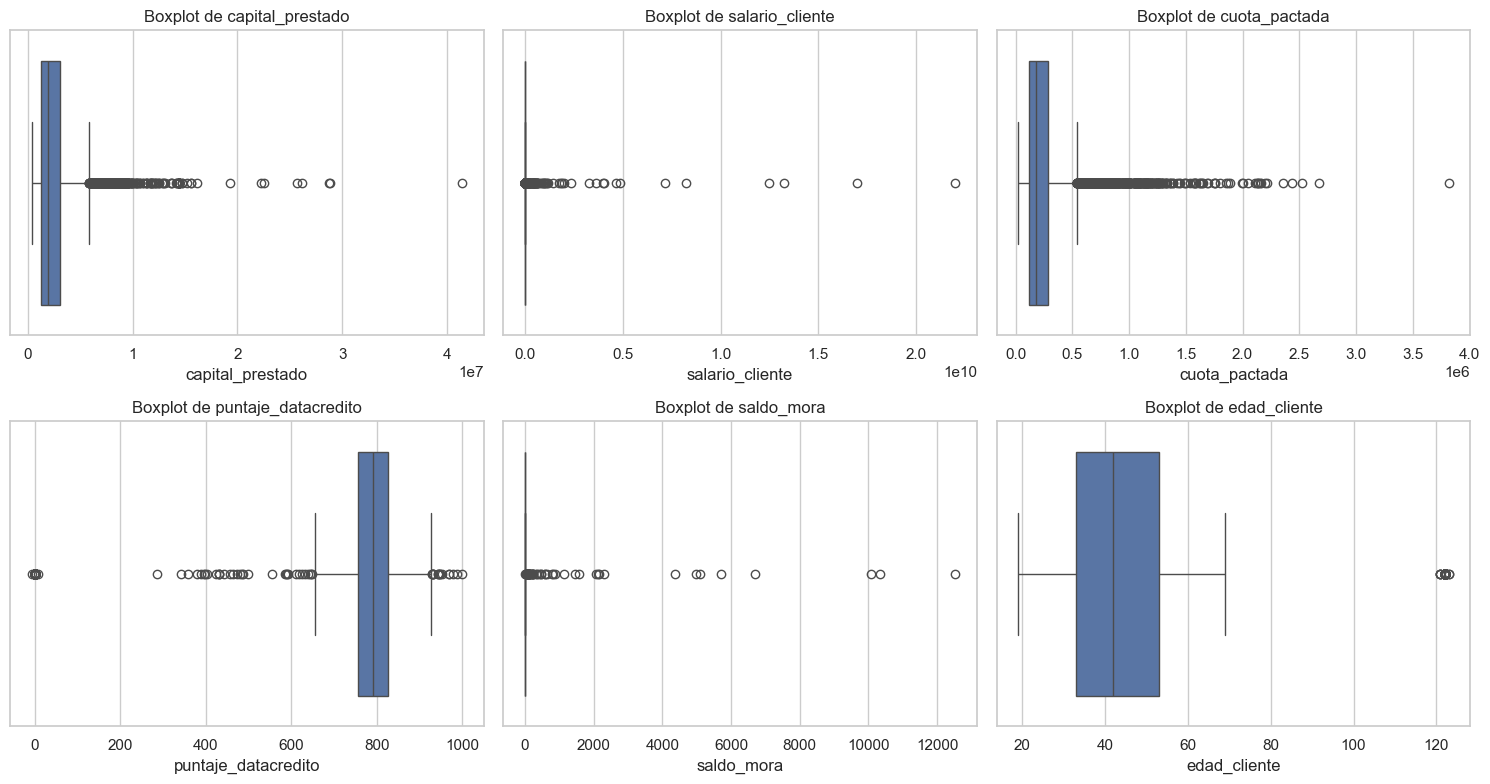

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), plot_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(f"Boxplot de {col}")
plt.tight_layout()

## 8. Analisis univariable categorico

Se revisan frecuencias de variables nominales y ordinales. `tipo_credito` esta concentrado principalmente en dos codigos, y `tipo_laboral` separa empleados e independientes.

In [10]:
categorical_cols = ["tipo_credito", "tipo_laboral", "tendencia_ingresos", TARGET]
for col in categorical_cols:
    display(df[col].value_counts(dropna=False).rename("conteo").to_frame())

,conteo
tipo_credito,
4,7747
9,2876
10,116
6,21
7,2
68,1


,conteo
tipo_laboral,
Empleado,6754
Independiente,4009


,conteo
tendencia_ingresos,
Creciente,5294
Desconocido,2990
Decreciente,1291
Estable,1188


,conteo
Pago_atiempo,
1,10252
0,511


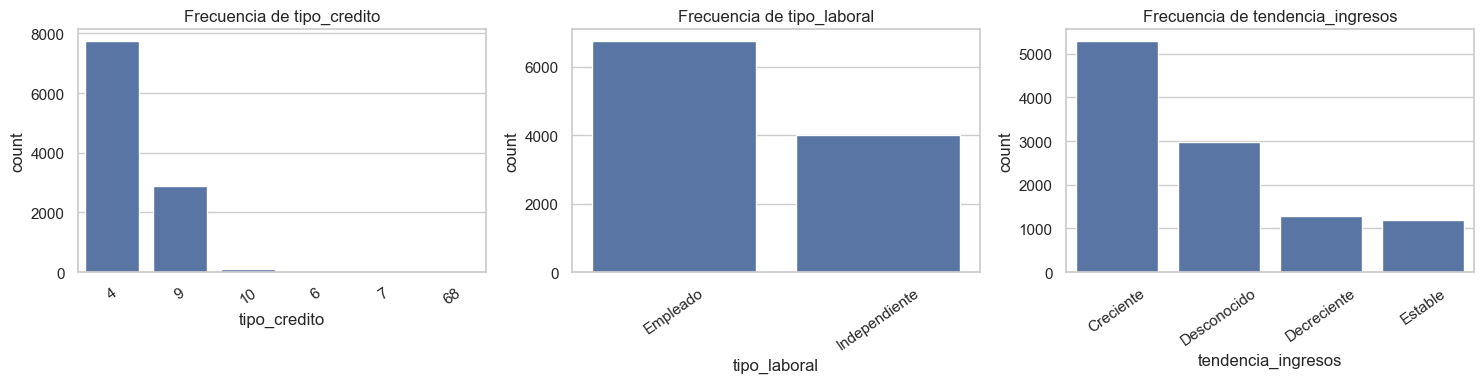

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["tipo_credito", "tipo_laboral", "tendencia_ingresos"]):
    sns.countplot(data=df, x=col, ax=ax, order=df[col].value_counts().index)
    ax.set_title(f"Frecuencia de {col}")
    ax.tick_params(axis="x", rotation=35)
plt.tight_layout()

## 9. Analisis bivariado contra la variable objetivo

Se compara cada grupo contra `Pago_atiempo`. Como la base esta desbalanceada hacia pago a tiempo, se revisan tasas y no solo conteos.

In [12]:
target_rate = df[TARGET].mean()
print(f"Tasa global de pago a tiempo: {target_rate:.2%}")
by_category = []
for col in ["tipo_credito", "tipo_laboral", "tendencia_ingresos"]:
    table = df.groupby(col)[TARGET].agg(["count", "mean"]).sort_values("mean")
    table["variable"] = col
    by_category.append(table.reset_index().rename(columns={col: "valor", "mean": "tasa_pago_atiempo"}))
pd.concat(by_category, ignore_index=True)

Tasa global de pago a tiempo: 95.25%


,valor,count,tasa_pago_atiempo,variable
0,6,21,0.5714,tipo_credito
1,9,2876,0.9527,tipo_credito
2,4,7747,0.9531,tipo_credito
3,10,116,0.9741,tipo_credito
4,68,1,1.0000,tipo_credito
5,7,2,1.0000,tipo_credito
6,Independiente,4009,0.9449,tipo_laboral
7,Empleado,6754,0.9571,tipo_laboral
8,Decreciente,1291,0.9373,tendencia_ingresos
9,Desconocido,2990,0.9438,tendencia_ingresos


In [13]:
bivariate_cols = ["capital_prestado", "salario_cliente", "cuota_pactada", "puntaje_datacredito", "saldo_mora", "huella_consulta"]
summary_by_target = df.groupby(TARGET)[bivariate_cols].agg(["mean", "median"]).T
summary_by_target

Pago_atiempo                             0               1
capital_prestado    mean    2,781,774.1127  2,416,996.2727
                    median  2,268,000.0000  1,908,446.4000
salario_cliente     mean   23,555,143.3268 16,900,485.1310
                    median  3,000,000.0000  3,000,000.0000
cuota_pactada       mean      254,755.6908    243,062.2308
                    median    199,002.0000    182,576.0000
puntaje_datacredito mean          748.8804        782.3790
                    median        768.0000        792.0000
saldo_mora          mean           82.3680          4.0544
                    median          0.0000          0.0000
huella_consulta     mean            5.2407          4.1781
                    median          5.0000          4.0000

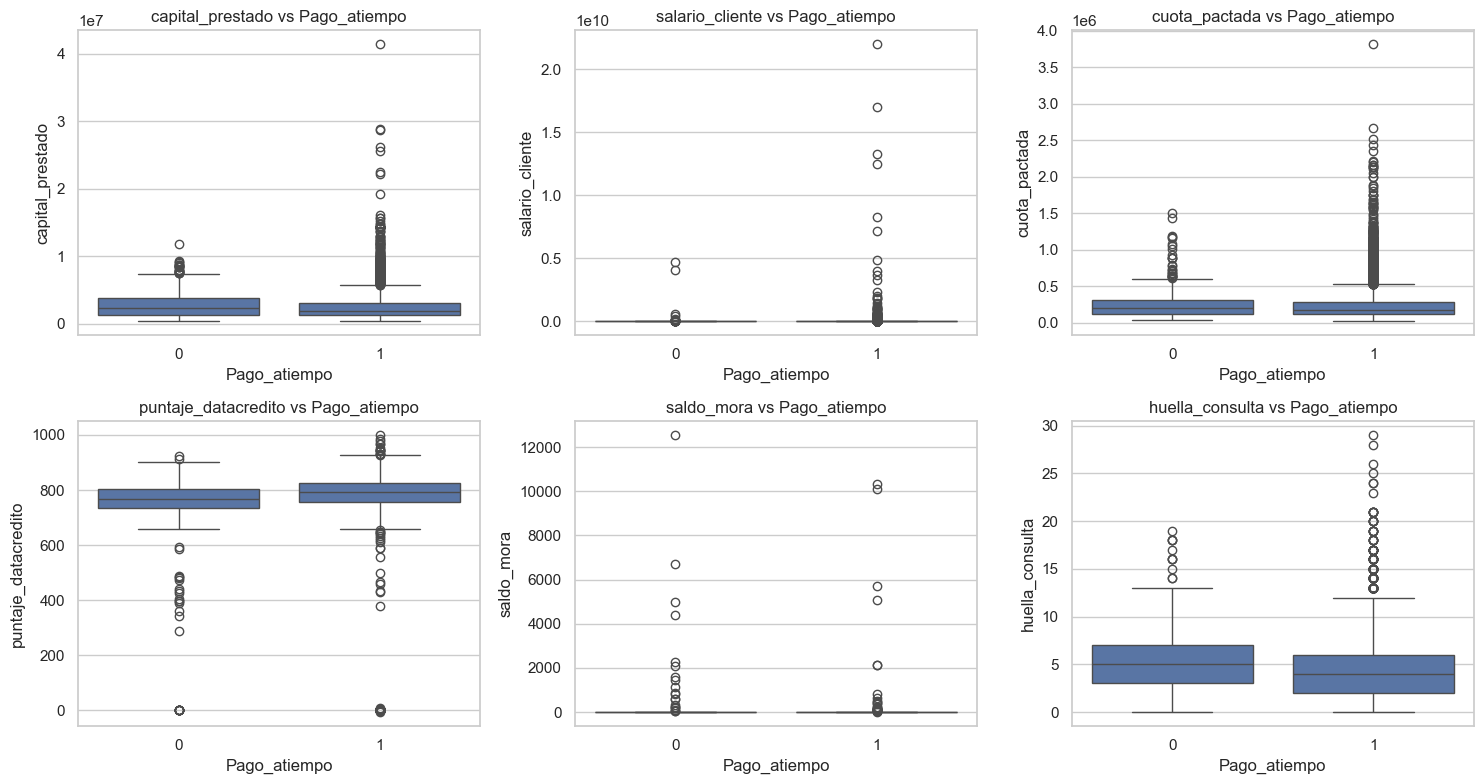

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), bivariate_cols):
    sns.boxplot(data=df, x=TARGET, y=col, ax=ax)
    ax.set_title(f"{col} vs {TARGET}")
plt.tight_layout()

## 10. Analisis multivariable

Se revisan correlaciones y combinaciones entre variables. Esto ayuda a detectar redundancia, posibles transformaciones y variables que conviene monitorear en produccion.

Text(0.5, 1.0, 'Matriz de correlacion')

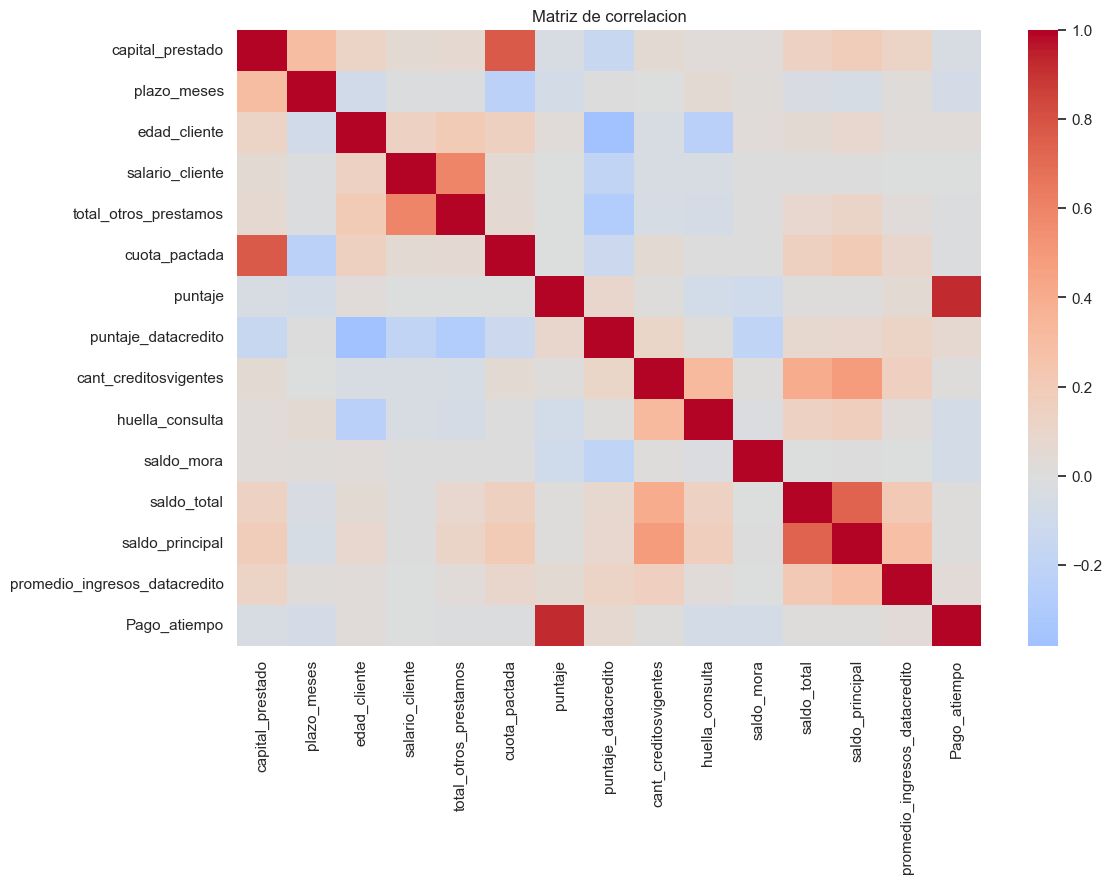

In [15]:
corr_cols = [
    "capital_prestado", "plazo_meses", "edad_cliente", "salario_cliente",
    "total_otros_prestamos", "cuota_pactada", "puntaje", "puntaje_datacredito",
    "cant_creditosvigentes", "huella_consulta", "saldo_mora", "saldo_total",
    "saldo_principal", "promedio_ingresos_datacredito", TARGET
]
corr = df[corr_cols].corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matriz de correlacion")

In [16]:
pivot_pago = pd.pivot_table(
    df, values=TARGET, index="tipo_laboral", columns="tipo_credito", aggfunc="mean"
).round(4)
pivot_pago

tipo_credito,10,4,6,68,7,9
tipo_laboral,,,,,,
Empleado,0.9733,0.9586,0.5714,1.0000,1.0000,0.9564
Independiente,0.9756,0.9429,NaN,NaN,1.0000,0.9481


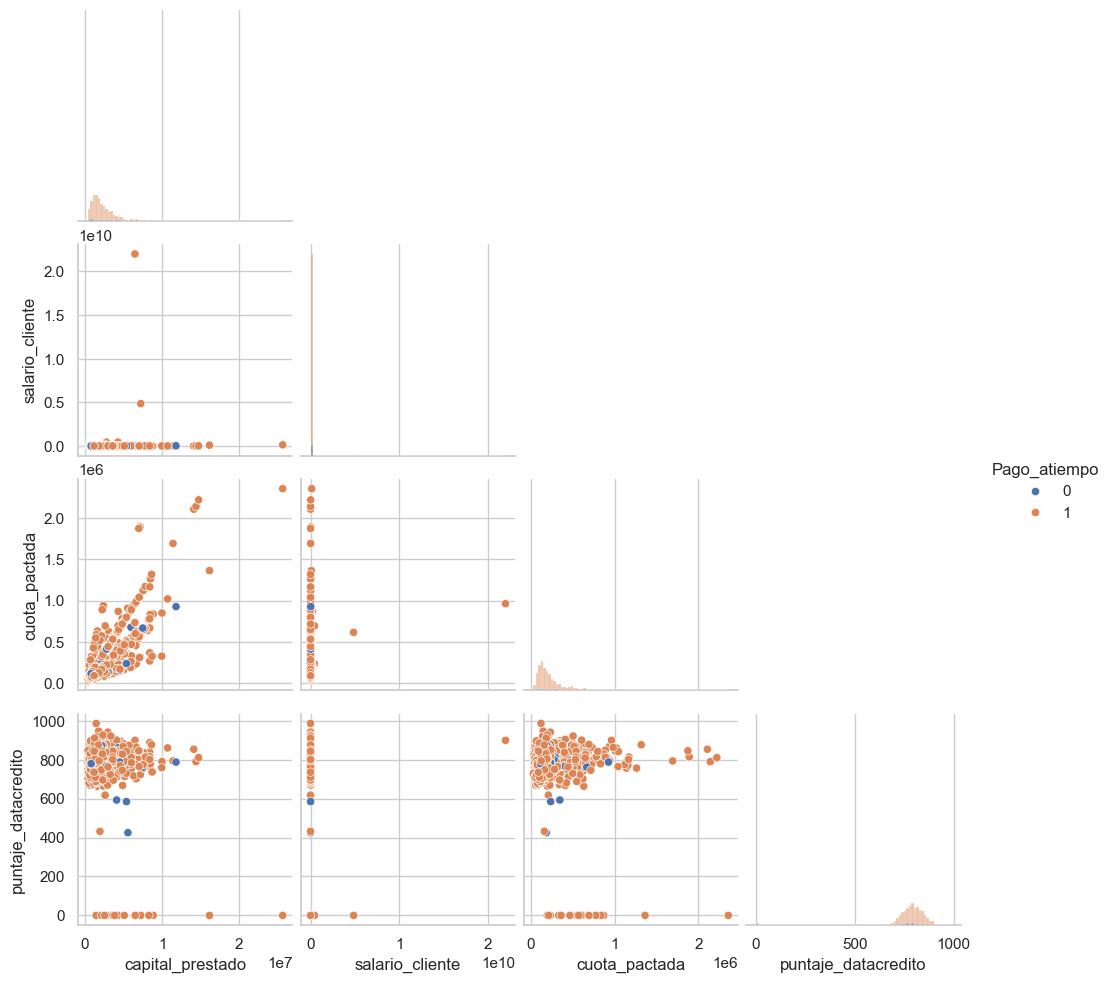

In [17]:
sample = df.sample(min(1500, len(df)), random_state=42)
sns.pairplot(
    sample[["capital_prestado", "salario_cliente", "cuota_pactada", "puntaje_datacredito", TARGET]],
    hue=TARGET,
    diag_kind="hist",
    corner=True,
)

## 11. Features derivadas utiles

A partir del EDA se crean variables de razon financiera y banderas de mora. Estas features son mas interpretables que montos aislados porque relacionan deuda, cuota e ingresos.

In [18]:
derived_cols = [col for col in featured_df.columns if col not in df.columns]
featured_df[derived_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
prestamo_year,"10,763.0000","2,024.8933",0.3775,"2,024.0000","2,025.0000","2,025.0000","2,025.0000","2,026.0000"
prestamo_month,"10,763.0000",5.2741,3.7175,1.0000,2.0000,4.0000,8.0000,12.0000
cuota_salario_ratio,"10,763.0000",841.5948,"29,826.4290",0.0000,0.0388,0.0609,0.0956,"2,671,342.0000"
capital_salario_ratio,"10,763.0000","9,288.1076","293,695.4170",0.0001,0.3706,0.6340,1.0247,"22,502,400.0000"
otros_prestamos_salario_ratio,"10,763.0000",582.9563,"31,302.0688",0.0000,0.2083,0.3333,0.4750,"2,000,000.0000"
carga_total_salario_ratio,"10,763.0000","1,424.5510","45,872.5567",0.0000,0.2881,0.4217,0.5443,"2,671,342.0000"
capital_por_mes,"10,763.0000","272,436.5586","241,848.4935","22,700.0000","129,559.1200","201,601.5600","320,944.0000","4,144,415.2800"
mora_ratio,"10,607.0000",0.0004,0.0137,0.0000,0.0000,0.0000,0.0000,1.0000
saldo_principal_ratio,"10,358.0000",0.8768,0.2936,0.0000,1.0000,1.0000,1.0000,1.0000
has_mora,"10,763.0000",0.0051,0.0713,0.0000,0.0000,0.0000,0.0000,1.0000


## 12. Reglas de validacion propuestas

Estas reglas se usan como control conceptual para futuras cargas y para monitoreo. Si se rompen en produccion, el modelo puede estar recibiendo datos fuera del contexto de entrenamiento.

In [19]:
validation_rules = pd.DataFrame([
    ["Pago_atiempo", "Debe ser 0 o 1", "Objetivo binario"],
    ["fecha_prestamo", "Debe convertirse a fecha valida", "Necesaria para split temporal y monitoreo"],
    ["edad_cliente", "Debe ser >= 18", "No se esperan menores de edad"],
    ["plazo_meses", "Debe ser >= 1", "Un credito no puede tener plazo cero"],
    ["capital_prestado", "Debe ser >= 0", "Monto negativo no es valido"],
    ["salario_cliente", "Debe ser >= 0", "Se imputa si falta, pero no debe ser negativo"],
    ["tipo_laboral", "Empleado o Independiente", "Categorias vistas en entrenamiento"],
    ["tipo_credito", "Categoria conocida o Desconocido", "Variable nominal del producto"],
    ["puntaje_datacredito", "Rango esperado 0 a 1000", "Puntaje externo de credito"],
    ["saldo_mora", "Debe ser >= 0", "Mora negativa no tiene sentido"],
], columns=["variable", "regla", "motivo"])
validation_rules

,variable,regla,motivo
0,Pago_atiempo,Debe ser 0 o 1,Objetivo binario
1,fecha_prestamo,Debe convertirse a fecha valida,Necesaria para split temporal y monitoreo
2,edad_cliente,Debe ser >= 18,No se esperan menores de edad
3,plazo_meses,Debe ser >= 1,Un credito no puede tener plazo cero
4,capital_prestado,Debe ser >= 0,Monto negativo no es valido
5,salario_cliente,Debe ser >= 0,"Se imputa si falta, pero no debe ser negativo"
6,tipo_laboral,Empleado o Independiente,Categorias vistas en entrenamiento
7,tipo_credito,Categoria conocida o Desconocido,Variable nominal del producto
8,puntaje_datacredito,Rango esperado 0 a 1000,Puntaje externo de credito
9,saldo_mora,Debe ser >= 0,Mora negativa no tiene sentido


## 13. Conclusiones del EDA

- La base corresponde al PI financiero y contiene 10,763 solicitudes historicas.
- `Pago_atiempo` esta muy desbalanceada: la mayoria de registros pago a tiempo. Por eso el avance de modelado debe revisar metricas robustas como ROC-AUC y balanced accuracy.
- Las columnas de mora, saldo, ingresos y puntajes son las mas importantes para vigilar porque pueden cambiar con el tiempo y afectar el scoring.
- Los nulos no obligan a eliminar filas; se tratan con imputacion numerica o categoria `Desconocido`.
- Las transformaciones principales son razones financieras, banderas de mora y variables temporales derivadas de `fecha_prestamo`.
- `loan_id` y la fecha cruda no deben entrar directamente al modelo como variables predictoras.